In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

# Load metrics
with open("../models/metrics_comparison.json", "r") as f:
    metrics = json.load(f)

# Load data
df = pd.read_csv("../data/processed/features_toba.csv", parse_dates=["date"])
balige = df[df["location"] == "Balige (Tobasa)"].copy()
balige = balige.sort_values("date").reset_index(drop=True)

print("Semua data & metrics loaded!")
print(f"Model tersedia: {list(metrics.keys())}")

Semua data & metrics loaded!
Model tersedia: ['SARIMA', 'Prophet', 'LSTM']


In [2]:
# Buat DataFrame perbandingan
rows = []
for model_name, m in metrics.items():
    rows.append({
        "Model"  : model_name,
        "MAE (°C)": round(m["MAE"], 3),
        "RMSE (°C)": round(m["RMSE"], 3),
        "MAPE (%)" : round(m["MAPE"], 3),
        "R²"       : round(m["R2"], 4),
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.set_index("Model")

print("   PERBANDINGAN LENGKAP — SEMUA MODEL")
print(comparison_df.to_string())

# Highlight model terbaik per metrik
print("\nModel terbaik per metrik:")
for col in ["MAE (°C)", "RMSE (°C)", "MAPE (%)"]:
    best = comparison_df[col].idxmin()
    print(f"  {col:<12} → {best}")
print(f"  {'R²':<12} → {comparison_df['R²'].idxmax()}")

   PERBANDINGAN LENGKAP — SEMUA MODEL
         MAE (°C)  RMSE (°C)  MAPE (%)      R²
Model                                         
SARIMA      0.933      1.112     3.238 -0.0978
Prophet     0.726      0.884     2.558  0.3074
LSTM        0.490      0.629     1.701  0.6487

Model terbaik per metrik:
  MAE (°C)     → LSTM
  RMSE (°C)    → LSTM
  MAPE (%)     → LSTM
  R²           → LSTM


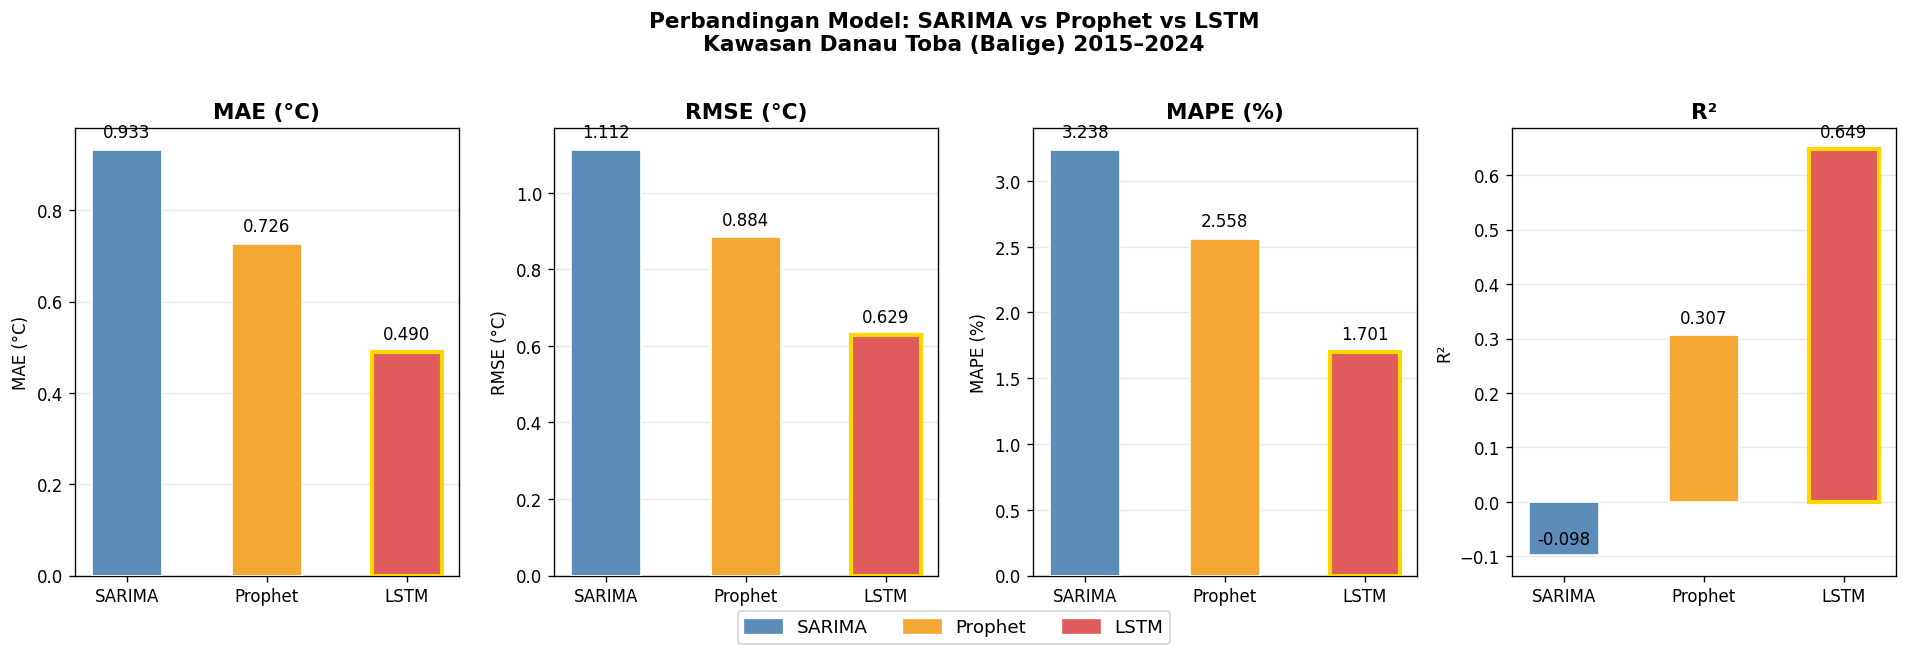

Chart tersimpan


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

colors = {
    "SARIMA" : "#5B8DB8",
    "Prophet": "#F4A833",
    "LSTM"   : "#E05C5C"
}

models = list(metrics.keys())
bar_colors = [colors[m] for m in models]

metrics_to_plot = [
    ("MAE (°C)",  "MAE",  False),
    ("RMSE (°C)", "RMSE", False),
    ("MAPE (%)",  "MAPE", False),
    ("R²",        "R2",   True),   # True = higher is better
]

for ax, (label, key, higher_better) in zip(axes, metrics_to_plot):
    vals = [metrics[m][key] for m in models]
    bars = ax.bar(models, vals, color=bar_colors, edgecolor="white",
                  width=0.5, zorder=3)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_ylabel(label)

    # Label nilai di atas bar
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(max(vals)) * 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

    # Highlight bar terbaik
    best_idx = vals.index(max(vals) if higher_better else min(vals))
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(2.5)

# Legend
patches = [mpatches.Patch(color=colors[m], label=m) for m in models]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("Perbandingan Model: SARIMA vs Prophet vs LSTM\nKawasan Danau Toba (Balige) 2015–2024",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("../data/processed/12_model_comparison_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart tersimpan")

In [4]:
series = balige["temperature_2m_max"].values
dates  = pd.to_datetime(balige["date"].values)
split_idx = int(len(series) * 0.8)

# SARIMA
train_s = pd.Series(series[:split_idx], index=dates[:split_idx])
test_s  = pd.Series(series[split_idx:], index=dates[split_idx:])

sarima_model = pickle.load(open("../models/arima_model.pkl", "rb"))
sarima_pred  = sarima_model.get_forecast(steps=len(test_s)).predicted_mean.values

# Prophet 
prophet_model = pickle.load(open("../models/prophet_model.pkl", "rb"))
prophet_df    = balige[["date","temperature_2m_max"]].rename(
    columns={"date":"ds","temperature_2m_max":"y"})
future        = prophet_model.make_future_dataframe(periods=len(test_s), freq="D")
forecast_p    = prophet_model.predict(future)
prophet_pred  = forecast_p[forecast_p["ds"].isin(
    pd.to_datetime(balige["date"].values[split_idx:]))]["yhat"].values

# LSTM 
WINDOW = 14
scaler = pickle.load(open("../models/lstm_scaler.pkl", "rb"))
lstm_model = tf.keras.models.load_model("../models/lstm_model.keras")

series_scaled = scaler.fit_transform(series.reshape(-1,1)).flatten()
X_all = np.array([series_scaled[i:i+WINDOW] for i in range(len(series_scaled)-WINDOW)])
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)
X_test_lstm = X_all[split_idx:]
lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

test_dates = dates[split_idx:]
actual     = series[split_idx:]

print(f"Prediksi regenerated:")
print(f"  SARIMA  : {len(sarima_pred)} hari")
print(f"  Prophet : {len(prophet_pred)} hari")
print(f"  LSTM    : {len(lstm_pred)} hari")

Prediksi regenerated:
  SARIMA  : 725 hari
  Prophet : 725 hari
  LSTM    : 711 hari


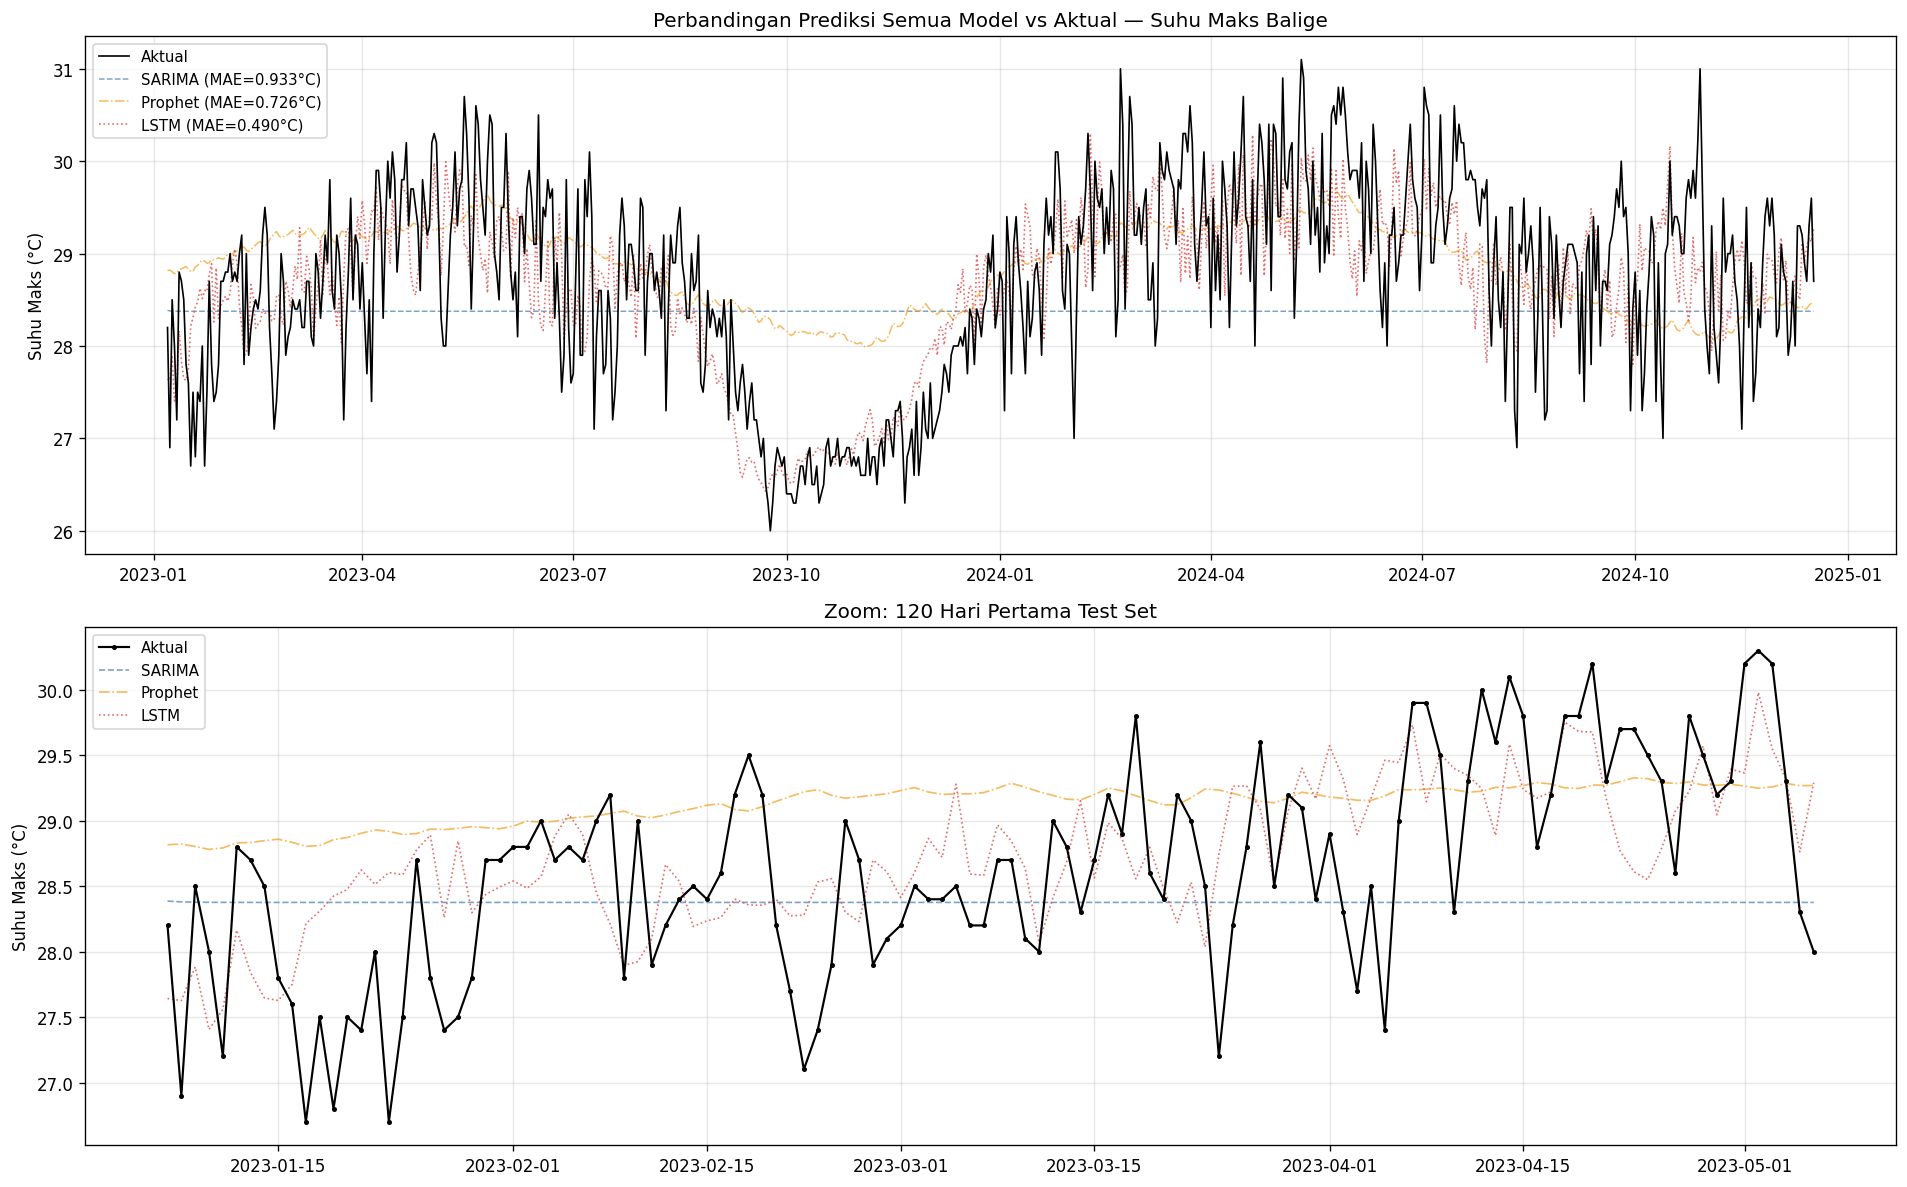

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

min_len = min(len(sarima_pred), len(prophet_pred), len(lstm_pred), len(actual))
td = test_dates[:min_len]
ac = actual[:min_len]
sp = sarima_pred[:min_len]
pp = prophet_pred[:min_len]
lp = lstm_pred[:min_len]

# Plot 1: full test set
axes[0].plot(td, ac, color="black", linewidth=1,
             label="Aktual", zorder=5)
axes[0].plot(td, sp, color="#5B8DB8", linewidth=0.9,
             linestyle="--", label=f"SARIMA (MAE={metrics['SARIMA']['MAE']:.3f}°C)", alpha=0.8)
axes[0].plot(td, pp, color="#F4A833", linewidth=0.9,
             linestyle="-.", label=f"Prophet (MAE={metrics['Prophet']['MAE']:.3f}°C)", alpha=0.8)
axes[0].plot(td, lp, color="#E05C5C", linewidth=1,
             linestyle=":", label=f"LSTM (MAE={metrics['LSTM']['MAE']:.3f}°C)", alpha=0.9)
axes[0].set_title("Perbandingan Prediksi Semua Model vs Aktual — Suhu Maks Balige")
axes[0].set_ylabel("Suhu Maks (°C)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Plot 2: zoom 120 hari pertama
axes[1].plot(td[:120], ac[:120], color="black", linewidth=1.3,
             marker="o", markersize=2, label="Aktual", zorder=5)
axes[1].plot(td[:120], sp[:120], color="#5B8DB8", linewidth=1,
             linestyle="--", label="SARIMA", alpha=0.8)
axes[1].plot(td[:120], pp[:120], color="#F4A833", linewidth=1,
             linestyle="-.", label="Prophet", alpha=0.8)
axes[1].plot(td[:120], lp[:120], color="#E05C5C", linewidth=1,
             linestyle=":", label="LSTM", alpha=0.9)
axes[1].set_title("Zoom: 120 Hari Pertama Test Set")
axes[1].set_ylabel("Suhu Maks (°C)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/13_all_models_overlay.png",
            dpi=150, bbox_inches="tight")
plt.show()

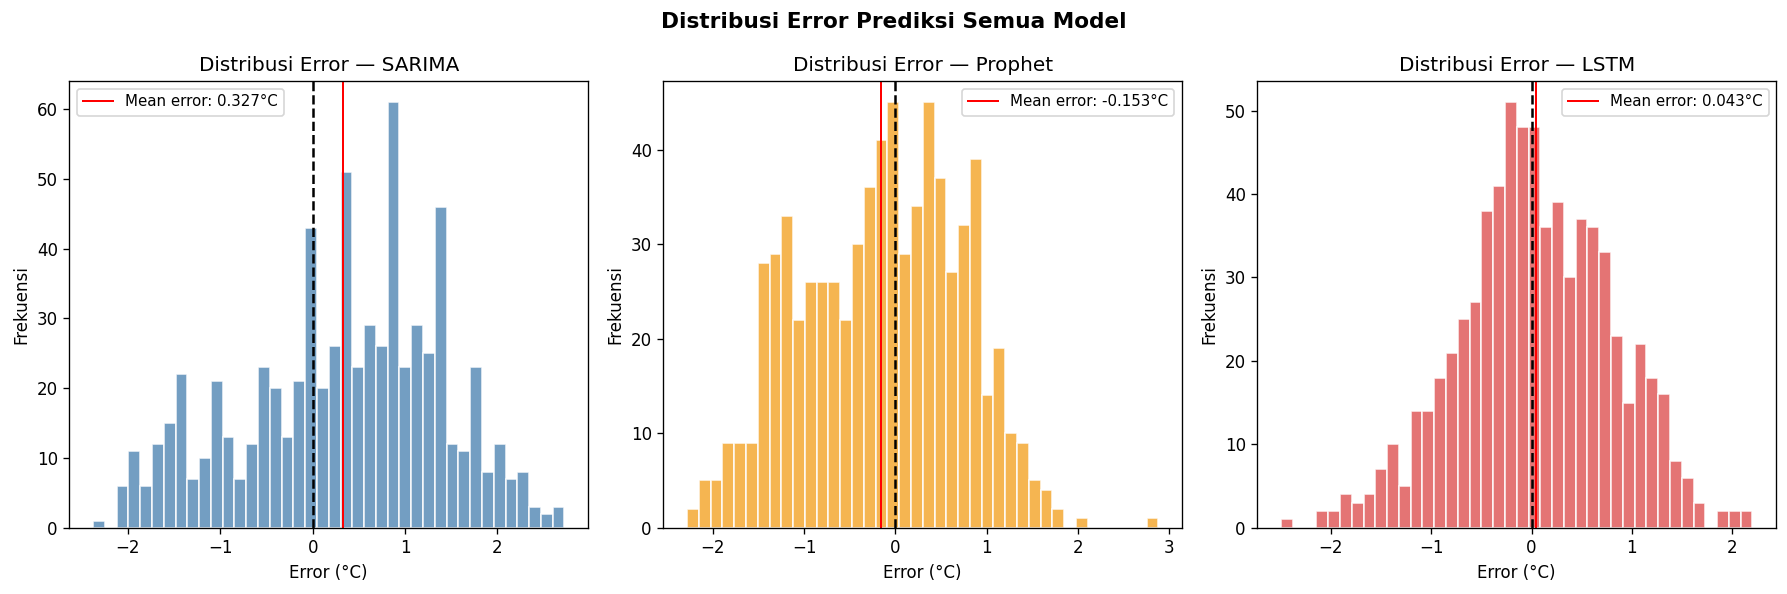

In [6]:
errors = {
    "SARIMA" : ac - sp,
    "Prophet": ac - pp,
    "LSTM"   : ac - lp,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (model_name, err) in zip(axes, errors.items()):
    ax.hist(err, bins=40, color=colors[model_name],
            edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax.axvline(err.mean(), color="red", linewidth=1.2,
               linestyle="-", label=f"Mean error: {err.mean():.3f}°C")
    ax.set_title(f"Distribusi Error — {model_name}")
    ax.set_xlabel("Error (°C)")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=9)

fig.suptitle("Distribusi Error Prediksi Semua Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/14_error_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("   RINGKASAN FINAL: LANGITTOBA MODEL COMPARISON")

print(f"\n{'Model':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'R²':>8}")
for m_name, m_val in metrics.items():
    marker = " " if m_name == "LSTM" else ""
    print(f"{m_name:<10} {m_val['MAE']:>8.3f} {m_val['RMSE']:>8.3f} "
          f"{m_val['MAPE']:>8.3f} {m_val['R2']:>8.4f}{marker}")

print("  KESIMPULAN")
print(f"""
1. SARIMA  → Model baseline klasik. MAE 0.933°C, R² negatif.
             Tidak mampu tangkap pola non-linear suhu Toba.

2. Prophet → Signifikan lebih baik dari SARIMA. MAE 0.726°C,
             R² 0.307. Berhasil tangkap seasonality tahunan
             dan mingguan.

3. LSTM    → Model terbaik di semua metrik. MAE 0.490°C,
             R² 0.649. Mampu tangkap dependensi temporal
             kompleks yang tidak bisa ditangkap model lain.

→ LSTM dipilih sebagai model yang di-deploy ke inference API.
→ Prophet disimpan sebagai fallback model.
""")

print("\nNotebook modeling selesai! Lanjut → FastAPI Inference Service")

   RINGKASAN FINAL: LANGITTOBA MODEL COMPARISON

Model           MAE     RMSE     MAPE       R²
SARIMA        0.933    1.112    3.238  -0.0978
Prophet       0.726    0.884    2.558   0.3074
LSTM          0.490    0.629    1.701   0.6487 
  KESIMPULAN

1. SARIMA  → Model baseline klasik. MAE 0.933°C, R² negatif.
             Tidak mampu tangkap pola non-linear suhu Toba.

2. Prophet → Signifikan lebih baik dari SARIMA. MAE 0.726°C,
             R² 0.307. Berhasil tangkap seasonality tahunan
             dan mingguan.

3. LSTM    → Model terbaik di semua metrik. MAE 0.490°C,
             R² 0.649. Mampu tangkap dependensi temporal
             kompleks yang tidak bisa ditangkap model lain.

→ LSTM dipilih sebagai model yang di-deploy ke inference API.
→ Prophet disimpan sebagai fallback model.


Notebook modeling selesai! Lanjut → FastAPI Inference Service
